# losses

> Soft cross-entropy, Laya's RLCD loss, temperature fitting, and the evaluation metrics of Laya's notebook: what each one computes, why it is there, and what went wrong on the way.

In [ ]:
#| default_exp losses

In [ ]:
#| export
import json, math
import numpy as np
import torch
import torch.nn.functional as F

from sysone.core import *

In [ ]:
#| hide
from fastcore.test import test_eq, test_close, test_fail
from sysone.metrics import Preds, rps as rps_metric
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "font.size": 9,
                     "axes.titlesize": 9, "legend.fontsize": 8, "legend.frameon": False})

A decision model is fitted twice. During training, a loss moves the weights until the probabilities at the anchors put their mass where the gold does. After training, one number per bucket of questions, a temperature, is fitted on rows the model never saw, so that a probability of 0.8 is right about 80% of the time. The metrics then check both:

```{mermaid}
flowchart LR
    Z["logits z<br/>(batch, K)"] -->|training| L{loss}
    L --> CE["soft cross-entropy<br/>(labels only)"]
    L --> RL["RLCD<br/>(soft gold, the default)"]
    Z -->|after training, on held-out rows| TF["fit_temperatures<br/>one T per type and option count"]
    TF --> P["p = softmax(z / T)"]
    P --> M["metrics: accuracy, Brier,<br/>KL, ECE, score MAE"]
```

A batch reaches the loss as logits (batch, K), the gold distributions over each row's options (batch, K, zero-padded), the marker mask saying which of the K slots are real, and the question types. Any callable with that signature works as a loss.

A toy batch: a four-option choice, a noul, and a four-level score whose gold is spread over neighbouring levels. The noul has two options, so its last two slots are padding, held at $-10^4$:

In [ ]:
logits = torch.tensor([[2.0, 0.5, -1.0, 0.0], [0.3, -0.3, -1e4, -1e4], [0.1, 1.2, 0.4, -0.5]])
target = torch.tensor([[0.8, 0.2, 0.0, 0.0], [0.4, 0.6, 0.0, 0.0], [0.1, 0.5, 0.3, 0.1]])
mask = torch.tensor([[1, 1, 1, 1], [1, 1, 0, 0], [1, 1, 1, 1]]).bool()
qtype = torch.tensor([QTYPES["choice"], QTYPES["noul"], QTYPES["score"]])

## Soft cross-entropy

The cross-entropy of each row's option probabilities against its gold distribution, the teacher's probabilities or a one-hot label,

$$\mathcal{L}_{\mathrm{CE}} = -\frac{1}{B}\sum_{b=1}^{B}\sum_{i=1}^{k_b} t_{b,i}\,\log p_{b,i}, \qquad p_b = \mathrm{softmax}(z_b).$$

It is the default when the data has labels only, and always the evaluation loss, since it has no noise.

In [ ]:
#| export
def soft_ce(logits, target, mask, qtype=None):
    "Mean cross-entropy of each row's option logits against its gold distribution"
    logp = torch.log_softmax(logits.float().masked_fill(~mask.bool(), -1e4), -1)
    return -(target * logp * mask).sum(-1).mean()

In [ ]:
manual = np.mean([-(target[i, :k] * torch.log_softmax(logits[i, :k], -1)).sum().item() for i, k in enumerate([4, 2, 4])])
test_close(soft_ce(logits, target, mask).item(), manual, eps=1e-5)

Its gradient with respect to a logit is the gap between the probability the model gives that option and the gold's, $\partial\mathcal{L}/\partial z_{b,i} = (p_{b,i} - t_{b,i})/B$: every option of a row moves at once, towards its gold probability, in proportion to how wrong it is. A padded slot has probability 0 and target 0 (the [masked softmax](03_models.ipynb#decisionhead) that makes it so is drawn in the models notebook), so its gradient is exactly zero, and padding needs no special case in the backward pass:

In [ ]:
z = logits.clone().requires_grad_(True)
soft_ce(z, target, mask).backward()
p = torch.softmax(logits.masked_fill(~mask, -1e4), -1)
test_close(z.grad, (p - target) / len(z), eps=1e-6)
test_eq(z.grad[~mask].abs().max().item(), 0.0)
z.grad

tensor([[-0.0300, -0.0139,  0.0118,  0.0320],
        [ 0.0819, -0.0819,  0.0000,  0.0000],
        [ 0.0231,  0.0030, -0.0238, -0.0023]])

## Proper scoring rules

A scoring rule pays a reported distribution $q$ once the outcome $i$ is known: the log score pays $\log q_i$, the spherical score $q_i/\lVert q\rVert$. A rule is *strictly proper* when its expected payment under the true distribution $t$, $\sum_i t_i\,S(q, i)$, is highest at $q = t$ and nowhere else. A model paid by a proper rule earns most by reporting what it believes, so it is paid for calibration and not only for the argmax.

RLCD's reward is the log score plus a weight of the spherical score, minus, for ordered score questions, the *ranked probability score*, $\frac{1}{k-1}\sum_j (Q_j - T_j)^2$ over the cumulative distributions $Q$ and $T$, which charges for probability placed far from the gold level. The function is Laya's `proper_reward`, vendored (Apache-2.0, Convai Innovations) so the core installs without Laya.

In [ ]:
#| exports
def proper_reward(q, target, qtype, mask, w_sph:float=0.5, w_rps:float=1.0, log_floor:float=-9.21):
    "Log score + w_sph × spherical score − w_rps × ranked probability score (score questions only); from Laya"
    q = q * mask
    logq = torch.log(q.clamp_min(1e-12)).clamp_min(log_floor)
    log_score = (target * logq).sum(-1)
    sph = (target * q).sum(-1) / q.norm(dim=-1).clamp_min(1e-9)
    r = log_score + w_sph * sph
    is_score = (qtype == QTYPES["score"]).float()
    k = mask.sum(-1).clamp(min=2).float()      # computed for every row and zeroed where not a score: no branch on the data (XLA)
    cdf_q, cdf_t = torch.cumsum(q, -1), torch.cumsum(target, -1)
    rps = (((cdf_q - cdf_t) ** 2) * mask).sum(-1) / (k - 1)
    r = r - w_rps * rps * is_score
    return r

On a yes/no question whose true probability is 0.7, the expected reward of each part of RLCD's reward, computed with `proper_reward` itself, peaks at a report of 0.7. The linear score $\sum_i t_i q_i$ looks just as reasonable and is not proper: it peaks at 1, paying the model to be overconfident.

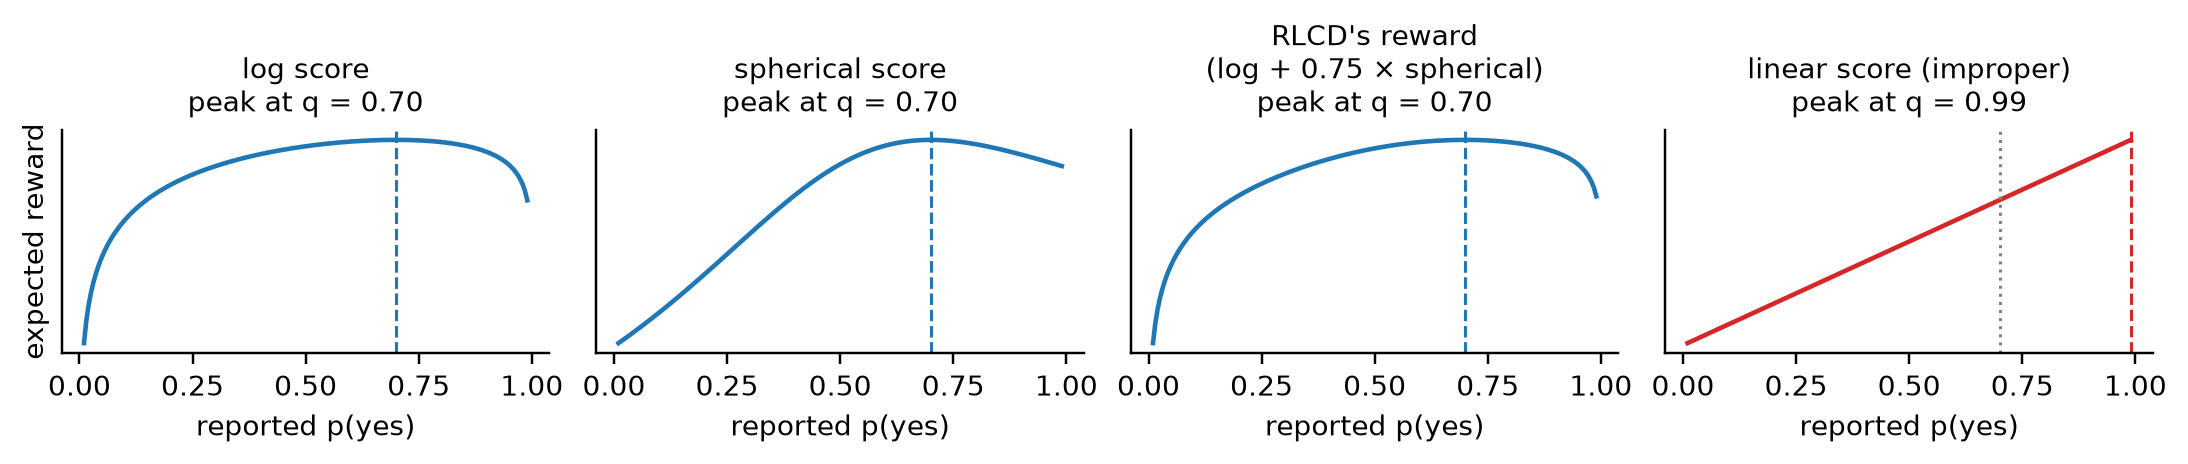

In [ ]:
#| code-fold: true
#| code-summary: figure code
qg = torch.linspace(0.01, 0.99, 197)
Q2, T2 = torch.stack([1 - qg, qg], -1), torch.tensor([[0.3, 0.7]])
m2, ch1 = torch.ones(1, 2).bool(), torch.tensor([QTYPES["choice"]])
logs = proper_reward(Q2, T2, ch1, m2, w_sph=0.0)
curves = {"log score": logs, "spherical score": proper_reward(Q2, T2, ch1, m2, w_sph=1.0) - logs,
          "RLCD's reward\n(log + 0.75 × spherical)": proper_reward(Q2, T2, ch1, m2, w_sph=0.75),
          "linear score (improper)": (Q2 * T2).sum(-1)}
fig, axs = plt.subplots(1, 4, figsize=(10, 2.2), sharex=True)
for ax, (name, c) in zip(axs, curves.items()):
    best = qg[c.argmax()].item()
    ax.plot(qg, c, color="C3" if "improper" in name else "C0")
    ax.axvline(0.7, color="gray", ls=":", lw=1); ax.axvline(best, color="C3" if "improper" in name else "C0", ls="--", lw=1)
    ax.set_title(f"{name}\npeak at q = {best:.2f}"); ax.set_yticks([]); ax.set_xlabel("reported p(yes)")
axs[0].set_ylabel("expected reward"); plt.tight_layout(); plt.show()

On a score question the order of the levels matters too. With the gold on level 1 of 4 and all the reported mass on one level, the log score cannot tell a near miss from a far one (both give the gold level zero probability and hit the floor, $\log 10^{-4} \approx -9.21$); the ranked probability score charges a near miss a third and a miss by two levels two thirds:

In [ ]:
gold1, m4, sc = torch.tensor([[0.0, 1.0, 0.0, 0.0]]), torch.ones(1, 4).bool(), torch.tensor([QTYPES["score"]])
rep = torch.eye(4)                                  # all the mass on level 0, 1, 2 or 3
as_choice = proper_reward(rep, gold1, torch.tensor([QTYPES["choice"]]), m4)
as_score = proper_reward(rep, gold1, sc, m4)
pd.DataFrame({"log score": proper_reward(rep, gold1, sc, m4, w_sph=0.0, w_rps=0.0).numpy(),
              "RPS charged": (as_choice - as_score).numpy(), "reward on a score question": as_score.numpy()},
             index=[f"all on level {j}" for j in range(4)]).round(3)

,log score,RPS charged,reward on a score question
all on level 0,-9.21,0.333,-9.543
all on level 1,0.00,0.000,0.500
all on level 2,-9.21,0.333,-9.543
all on level 3,-9.21,0.667,-9.877


Reporting the gold distribution itself beats reporting its argmax, and a near miss costs less than a far one:

In [ ]:
t = torch.tensor([[0.1, 0.5, 0.3, 0.1]]); m = torch.ones(1, 4).bool()
honest = proper_reward(t, t, sc, m)
argmax = proper_reward(torch.tensor([[0.0, 1.0, 0.0, 0.0]]), t, sc, m)
near = proper_reward(torch.tensor([[0.0, 0.0, 1.0, 0.0]]), t, sc, m)
far = proper_reward(torch.tensor([[1.0, 0.0, 0.0, 0.0]]), t, sc, m)
assert honest > argmax > near and near > far - 1e-6
honest.item(), argmax.item(), near.item(), far.item()

(-0.8682824969291687,
 -4.414999961853027,
 -6.423666477203369,
 -8.565666198730469)

## RLCD

Laya's training loss, from its fine-tuning notebook. Soft cross-entropy pays the log score only. RLCD pays all of the reward above, spherical score and RPS included, and pays it through reinforcement learning, which needs no gradient of the reward, only its value. The logits $\mu$ of a row are read as the mean of a Gaussian *policy* over logit vectors, and one step of the loss is:

```{mermaid}
flowchart TB
    MU["logits μ of a row (k options)"] --> EPS["G = 4 noise draws εᵍ ~ N(0, σ²I) on the k options,<br/>each shifted to sum to zero"]
    EPS --> ZG["noisy logits zᵍ = μ + εᵍ"]
    ZG --> QG["qᵍ = softmax(zᵍ)"]
    QG --> RG["reward rᵍ = log score + 0.75 · spherical − RPS"]
    RG --> AG["advantage Aᵍ = (rᵍ − the group's mean reward) / std"]
    AG --> PG["REINFORCE term: −Aᵍ · log π(zᵍ | μ)"]
    MU --> CE["soft cross-entropy (μ, t)"]
    PG --> LOSS(("loss"))
    CE --> LOSS
```

1. **Explore.** Draw $G = 4$ noisy copies of the logits, $z^g = \mu + \varepsilon^g$, with Gaussian noise on the row's real options only, and subtract from each draw its mean over the options.
2. **Score.** Softmax each copy and reward it with the proper scoring rules against the gold.
3. **Compare.** A copy's *advantage* is its reward minus its group's mean reward (the GRPO baseline), divided by the standard deviation of all the advantages in the batch.
4. **Reinforce.** A Gaussian policy has $\log\pi(z \mid \mu) = -\lVert z - \mu\rVert^2 / 2\sigma^2$ up to a constant, so the term $-A^g \log\pi(z^g \mid \mu)$ has gradient $-A^g\,\varepsilon^g/\sigma^2$ with respect to $\mu$. The logits move towards the copies that scored better than their group and away from those that scored worse. Averaged over draws this estimates the gradient of the noisy policy's expected reward: the score-function (REINFORCE) estimator.
5. **Guide.** Soft cross-entropy is added with weight 1, an exact, low-variance gradient towards the gold beside the noisy one.

σ is annealed from 0.4 to 0.1 over training. RLCD is the default loss when the gold is a distribution, as typed-decisions' is.

Step 1 on one row with three real options in a batch padded to four: the mask zeroes the noise on the padded slot, and subtracting each draw's mean over the real options leaves draws that sum to zero, the only part of the noise a softmax can see:

![Four noise draws before and after the projection, with their sums](images/rlcd_noise.svg)

*Drawn with RLCD's two lines of projection in [figures](90_figures.ipynb#rlcds-noise-draws).*

In [ ]:
#| exports
def rlcd_loss(logits, target, mask, qtype, sigma:float=0.4, group_size:int=4, w_sph:float=0.75, w_rps:float=1.0,
              ce_weight:float=1.0, generator=None):
    "REINFORCE on proper scoring rewards over `group_size` noisy copies of the logits, plus soft cross-entropy"
    logits, mask = logits.float(), mask.bool()
    k = mask.sum(-1, keepdim=True).float()
    eps = torch.randn((group_size,) + logits.shape, device=logits.device, generator=generator) * sigma * mask
    eps = (eps - eps.sum(-1, keepdim=True) / k) * mask
    z = logits.detach().unsqueeze(0) + eps
    q = torch.softmax(z.masked_fill(~mask, -1e4), -1)
    with torch.no_grad():
        r = proper_reward(q, target.unsqueeze(0), qtype, mask, w_sph=w_sph, w_rps=w_rps)
        adv = r - r.mean(0, keepdim=True)
        adv = adv / (adv.std() + 1e-6)
    logp = -(((z - logits.unsqueeze(0)) ** 2) * mask).sum(-1) / (2 * sigma ** 2)
    loss_rl = -(adv * logp).mean()
    loss_ce = -(target * torch.log_softmax(logits.masked_fill(~mask, -1e4), -1)).sum(-1).mean()
    return loss_rl + ce_weight * loss_ce

The same seed gives the notebook's number exactly; here is the notebook's code, pasted, next to it:

In [ ]:
def notebook_loss(logits, mask, target, qtype, GROUP_SIZE=4, sigma=0.4, GRAD_ACCUM=1):
    # pasted from laya_finetune_typed_decisions_2xT4_kaggle.ipynb, train_ddp.py, steps 1-3
    from laya.common import proper_reward
    device = logits.device
    k = mask.sum(-1, keepdim=True).float()
    eps = torch.randn((GROUP_SIZE,) + logits.shape, device=device) * sigma * mask
    eps = (eps - eps.sum(-1, keepdim=True) / k) * mask
    z = logits.detach().unsqueeze(0) + eps
    q = torch.softmax(z.masked_fill(~mask, -1e4), -1)
    with torch.no_grad():
        r = proper_reward(q, target.unsqueeze(0), qtype, mask, w_sph=0.75, w_rps=1.0)
        adv = r - r.mean(0, keepdim=True)
        adv = adv / (adv.std() + 1e-6)
    logp = -(((z - logits.unsqueeze(0)) ** 2) * mask).sum(-1) / (2 * sigma ** 2)
    loss_rl = -(adv * logp).mean()
    loss_ce = -(target * torch.log_softmax(logits.masked_fill(~mask, -1e4), -1)).sum(-1).mean()
    return (loss_rl + 1.0 * loss_ce) / GRAD_ACCUM

In [ ]:
torch.manual_seed(0); ours = rlcd_loss(logits, target, mask, qtype, sigma=0.4)
torch.manual_seed(0); theirs = notebook_loss(logits, mask, target, qtype)
test_eq(ours.item(), theirs.item())
ours.item()

-0.040978074073791504

### What the pieces do

Three experiments on free logits, where nothing but the loss is in play, show what each piece contributes.

**The projection removes noise that changes nothing.** Softmax ignores a shift of all the logits by the same amount, $\mathrm{softmax}(z + c\mathbf{1}) = \mathrm{softmax}(z)$, so the part of a noise draw along $\mathbf{1}$ changes no reward and only adds noise to the gradient estimate; subtracting each draw's mean removes it. Below, RLCD's estimate from G draws is compared with the exact gradient of the noisy policy's expected reward, computed by differentiating through 200,000 draws (the reparameterisation trick), for a four-level score question:

In [ ]:
mu = torch.tensor([[0.5, -0.2, 0.1, -0.4]]); t4 = torch.tensor([[0.1, 0.5, 0.3, 0.1]])
reward = lambda z: proper_reward(torch.softmax(z, -1), t4, sc, m4, w_sph=0.75)

def draws(n, sigma, project, gen):
    eps = torch.randn(n, 1, 4, generator=gen) * sigma
    return eps - eps.mean(-1, keepdim=True) if project else eps

def exact_grad(sigma=0.4, n=200_000):
    "∇μ E[r(softmax(μ + ε))], differentiating through the draws"
    m_ = mu.clone().requires_grad_(True)
    reward(m_ + draws(n, sigma, True, torch.Generator().manual_seed(1))).mean().backward()
    return m_.grad[0]

def reinforce_grad(G, gen, sigma=0.4, project=True):
    "RLCD's estimate of the same gradient from G draws: the mean of Aᵍ εᵍ / σ²"
    eps = draws(G, sigma, project, gen)
    r = reward(mu + eps); adv = r - r.mean(0, keepdim=True)
    return (adv[..., None] * eps / sigma ** 2).mean(0)[0]

g_exact, gen = exact_grad(), torch.Generator().manual_seed(0)
Gs = [4, 16, 64, 256, 1024]
cos = {p: [np.mean([F.cosine_similarity(reinforce_grad(G, gen, project=p), g_exact, 0).item() for _ in range(300)]) for G in Gs]
       for p in (True, False)}
along_ones = {p: np.std([reinforce_grad(4, gen, project=p).sum().item() for _ in range(300)]) for p in (True, False)}
assert all(a > b for a, b in zip(cos[True][:3], cos[False][:3])) and along_ones[True] < 1e-5
pd.DataFrame({"projected": cos[True], "raw draws": cos[False]}, index=[f"G = {G}" for G in Gs]).round(3), along_ones

(          projected  raw draws
 G = 4         0.733      0.659
 G = 16        0.933      0.902
 G = 64        0.983      0.975
 G = 256       0.996      0.994
 G = 1024      0.999      0.998,
 {True: np.float64(4.5389115940765663e-08),
  False: np.float64(0.5524720921532368)})

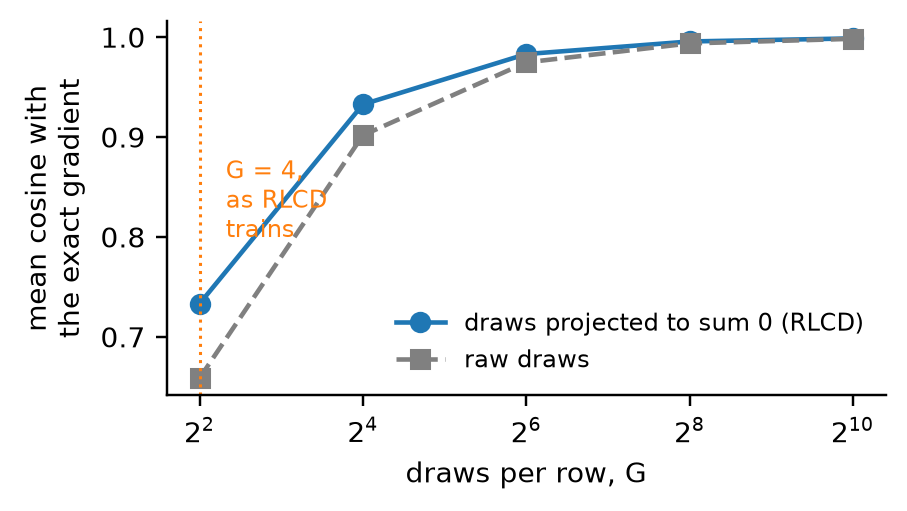

In [ ]:
#| code-fold: true
#| code-summary: figure code
fig, ax = plt.subplots(figsize=(4.2, 2.4))
ax.plot(Gs, cos[True], "o-", label="draws projected to sum 0 (RLCD)"); ax.plot(Gs, cos[False], "s--", color="gray", label="raw draws")
ax.axvline(4, color="C1", ls=":", lw=1); ax.text(5, 0.8, "G = 4,\nas RLCD\ntrains", color="C1", fontsize=8)
ax.set_xscale("log", base=2); ax.set_xlabel("draws per row, G"); ax.set_ylabel("mean cosine with\nthe exact gradient")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

With four draws, as RLCD trains, one estimate points the right way on average (a mean cosine of about 0.7) and is far from exact; the cross-entropy term is what keeps a step reliable. The projection helps at every group size, and leaves nothing at all along $\mathbf{1}$ (the standard deviation of that component, printed above, is 0 against about 0.5 for raw draws).

**σ moves the optimum, which is why it is annealed.** The average of the softmaxes of noisy logits is flatter than the softmax of their mean, so the logits that maximise the noisy policy's expected reward are *sharper* than the gold: the policy over-sharpens to make up for its own noise. The optimum, found by LBFGS over a fixed set of draws, for a three-option question with gold (0.6, 0.3, 0.1):

In [ ]:
t3, m3, ch = torch.tensor([[0.6, 0.3, 0.1]]), torch.ones(1, 3).bool(), torch.tensor([QTYPES["choice"]])
base = torch.randn(20_000, 1, 3, generator=torch.Generator().manual_seed(0)); base = base - base.mean(-1, keepdim=True)

def noisy_optimum(sigma):
    "softmax of the logits that maximise the expected reward of N(μ, σ²) noisy copies"
    mu_ = torch.log(t3).clone().requires_grad_(True)
    opt = torch.optim.LBFGS([mu_], max_iter=200, line_search_fn="strong_wolfe")
    def closure():
        opt.zero_grad(); loss = -proper_reward(torch.softmax(mu_ + sigma * base, -1), t3, ch, m3, w_sph=0.75).mean()
        loss.backward(); return loss
    opt.step(closure)
    return torch.softmax(mu_.detach(), -1)[0]

sigmas = [0.0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8]
opt_p = torch.stack([noisy_optimum(s) for s in sigmas])
kl = (t3 * (t3 / opt_p).log()).sum(-1)
assert kl[1] < 1e-4 < kl[4] and (kl[1:].diff() > 0).all()
pd.DataFrame(opt_p.numpy(), columns=["p₁ (gold 0.6)", "p₂ (gold 0.3)", "p₃ (gold 0.1)"], index=[f"σ = {s}" for s in sigmas]).assign(**{"KL(gold ‖ p)": kl.numpy()}).round(4)

,p₁ (gold 0.6),p₂ (gold 0.3),p₃ (gold 0.1),KL(gold ‖ p)
σ = 0.0,0.6000,0.3000,0.1000,0.0000
σ = 0.1,0.6018,0.2988,0.0995,0.0000
σ = 0.2,0.6068,0.2953,0.0980,0.0001
σ = 0.3,0.6143,0.2902,0.0955,0.0004
σ = 0.4,0.6236,0.2841,0.0922,0.0012
σ = 0.6,0.6457,0.2707,0.0836,0.0047
σ = 0.8,0.6701,0.2564,0.0735,0.0116


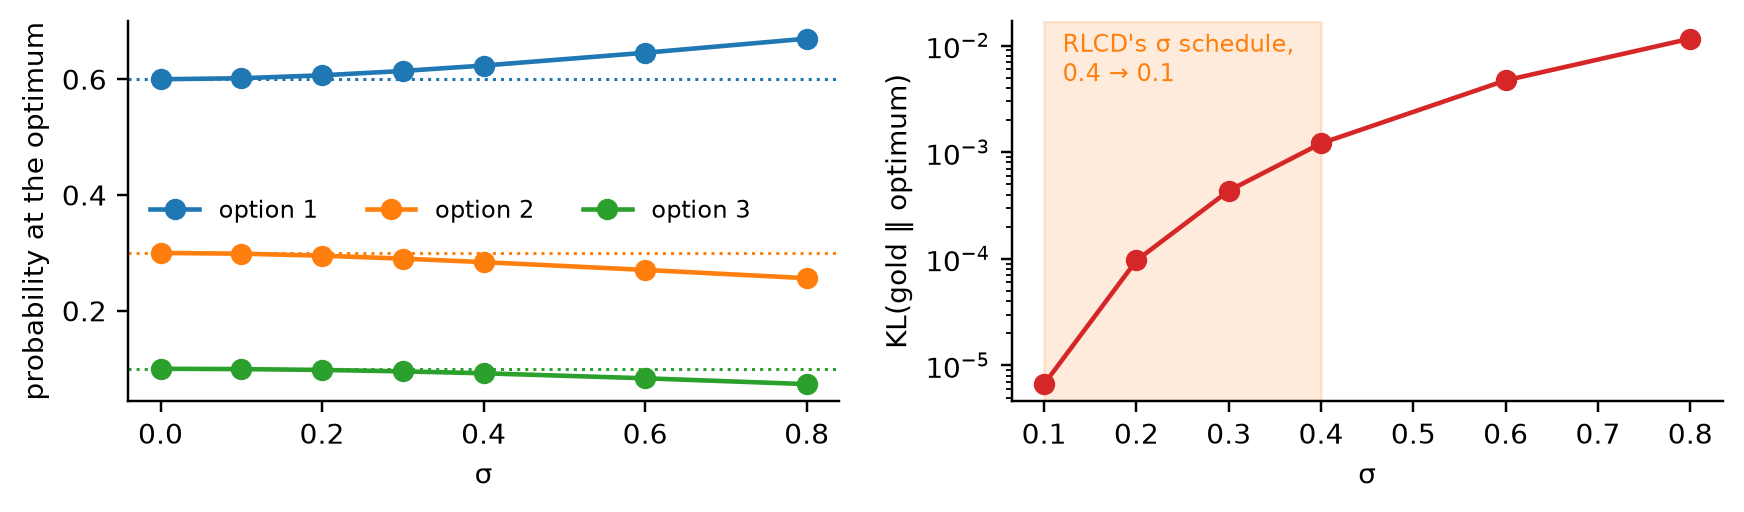

In [ ]:
#| code-fold: true
#| code-summary: figure code
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8, 2.4))
for i, g in enumerate(t3[0]):
    a1.plot(sigmas, opt_p[:, i], "o-", color=f"C{i}", label=f"option {i + 1}"); a1.axhline(g, color=f"C{i}", ls=":", lw=1)
a1.set_xlabel("σ"); a1.set_ylabel("probability at the optimum"); a1.legend(ncol=3, loc="center left")
a2.semilogy(sigmas[1:], kl[1:], "o-", color="C3"); a2.axvspan(0.1, 0.4, color="C1", alpha=0.15)
a2.text(0.12, kl[1:].max() * 0.4, "RLCD's σ schedule,\n0.4 → 0.1", color="C1", fontsize=8)
a2.set_xlabel("σ"); a2.set_ylabel("KL(gold ‖ optimum)")
plt.tight_layout(); plt.show()

The bias grows with σ², invisible at σ = 0.1 and a KL of about 0.001 at 0.4. Annealing σ from 0.4 to 0.1 explores widely early, when the logits are far from any optimum, and ends on an objective whose optimum is the gold.

**It converges, and keeps moving.** A few hundred steps of RLCD on free logits bring the reported distributions to the gold:

In [ ]:
def train_free(loss_fn, steps=300, seed=0):
    torch.manual_seed(seed)
    z = torch.zeros(3, 4, requires_grad=True); opt = torch.optim.Adam([z], lr=0.05); hist = []
    for _ in range(steps):
        opt.zero_grad(); loss_fn(z).backward(); opt.step()
        hist.append(torch.softmax(z.detach().masked_fill(~mask, -1e4), -1))
    return torch.stack(hist)

h_rlcd = train_free(lambda z: rlcd_loss(z, target, mask, qtype, sigma=0.2))
h_ce = train_free(lambda z: soft_ce(z, target, mask))
test_close(h_rlcd[-1], target, eps=0.08)
{"RLCD": h_rlcd[-100:].std(0).max().item(), "soft CE": h_ce[-100:].std(0).max().item()}

{'RLCD': 0.020456813275814056, 'soft CE': 0.0009159934124909341}

The numbers above are the largest standard deviation of any probability over the last 100 steps. The advantages are normalised to unit spread, so the REINFORCE term's gradient keeps its size as the model improves, where the cross-entropy's shrinks to zero at the optimum: RLCD's iterates keep jittering around the answer, and its logged training loss is noisier than a cross-entropy's. The learning rate's decay to zero (cosine, or one-cycle) is what lets a run settle.

`RLCD` wraps the loss with its σ schedule; the learner's `SigmaSchedule` callback sets the progress at every epoch, as the notebook anneals σ once per epoch:

In [ ]:
#| export
class RLCD:
    "Laya's RLCD loss with σ annealed from `sigma[0]` to `sigma[1]` over training"
    def __init__(self, sigma=(0.4, 0.1), group_size:int=4, w_sph:float=0.75, w_rps:float=1.0, ce_weight:float=1.0):
        self.sigma_start, self.sigma_end = sigma
        self.group_size, self.w_sph, self.w_rps, self.ce_weight, self.progress = group_size, w_sph, w_rps, ce_weight, 0.0
    @property
    def sigma(self) -> float: return self.sigma_start + (self.sigma_end - self.sigma_start) * self.progress
    def set_epoch(self, epoch:int, n_epochs:int): self.progress = min(1.0, epoch / max(1, n_epochs - 1))
    def __call__(self, logits, target, mask, qtype):
        return rlcd_loss(logits, target, mask, qtype, self.sigma, self.group_size, self.w_sph, self.w_rps, self.ce_weight)
    def __repr__(self): return f"RLCD(σ {self.sigma_start}→{self.sigma_end}, G={self.group_size}, w_sph={self.w_sph})"

In [ ]:
loss = RLCD()
test_eq([(loss.set_epoch(e, 4), round(loss.sigma, 3))[1] for e in range(4)], [0.4, 0.3, 0.2, 0.1])

`get_loss` resolves a name or a callable, and picks the default from the data: RLCD when some gold targets are distributions, soft cross-entropy when every target is one-hot.

In [ ]:
#| export
def is_soft(targets) -> bool:
    "Whether any target distribution is not one-hot (an unanswerable row's zero target does not count)"
    return any(max(t) < 1.0 - 1e-6 for t in targets if t is not None and len(t) and sum(t) > 0)

class SoftCE:
    "Soft cross-entropy over each row's options, plus `rps` × the ranked probability score on score rows (jev-dllm trains with 0.25)"
    def __init__(self, rps:float=0.25): self.rps, self.__name__ = float(rps), f"soft_ce_rps={float(rps):g}"
    def __call__(self, logits, target, mask, qtype=None):
        ce = soft_ce(logits, target, mask)
        if not self.rps or qtype is None: return ce
        m = mask.float()
        q = torch.softmax(logits.float().masked_fill(~mask.bool(), -1e4), -1) * m
        rps = (((q.cumsum(-1) - target.float().cumsum(-1)) ** 2) * m).sum(-1) / (m.sum(-1).clamp(min=2) - 1)
        return ce + self.rps * (rps * (qtype == QTYPES["score"]).float()).mean()     # score rows by a 0/1 flag, no branch
    def __repr__(self): return f"SoftCE(rps={self.rps:g})"

def get_loss(loss=None, targets=None):
    "The loss callable for a name ('soft_ce', 'rlcd', 'soft_ce_rps', or 'soft_ce_rps=w'), a callable, or the data's default"
    if callable(loss): return loss
    if loss is None: loss = "rlcd" if targets is not None and is_soft(targets) else "soft_ce"
    if loss == "soft_ce": return soft_ce
    if loss == "rlcd": return RLCD()
    if str(loss).startswith("soft_ce_rps"): return SoftCE(*([float(loss.split("=")[1])] if "=" in loss else []))
    raise ValueError(f"unknown loss {loss!r}; use 'soft_ce', 'rlcd', 'soft_ce_rps' or a callable(logits, target, mask, qtype)")

In [ ]:
test_eq(get_loss(targets=[[0, 1], [1, 0, 0]]), soft_ce)
assert isinstance(get_loss(targets=[[0.2, 0.8]]), RLCD)
test_fail(lambda: get_loss("hinge"), contains="unknown loss")

`SoftCE(rps=w)` adds `w` × the ranked probability score on score rows to the soft cross-entropy, the loss jev-dllm trains its Yes/No decisions with (w = 0.25). The RPS penalises a score's probability mass by how far it sits from the gold level, which cross-entropy alone ignores. Its name records the weight, so a learner reloaded from an export gets the same loss back:

In [ ]:
lg = torch.tensor([[2.0, 0.5, -1.0], [0.1, 0.2, 0.3], [1.0, -1.0, -1e4]]); tg = torch.tensor([[0.0, 1.0, 0.0], [0.0, 0.0, 1.0], [1.0, 0.0, 0.0]])
mk = torch.tensor([[1, 1, 1], [1, 1, 1], [1, 1, 0]]).bool(); qt = torch.tensor([QTYPES["score"], QTYPES["choice"], QTYPES["noul"]])
f = SoftCE(0.25)
r0 = float(rps_metric(Preds(lg[:1].numpy(), tg[:1].numpy(), mk[:1].numpy(), np.array([QTYPES["score"]]), np.array([1]))))
test_close(f(lg, tg, mk, qt), soft_ce(lg, tg, mk) + 0.25 * r0 / 3, eps=1e-5)            # the RPS of the one score row, averaged over the batch
test_close(SoftCE(0)(lg, tg, mk, qt), soft_ce(lg, tg, mk))
test_eq((f.__name__, repr(get_loss(f.__name__)), repr(get_loss("soft_ce_rps"))), ("soft_ce_rps=0.25", "SoftCE(rps=0.25)", "SoftCE(rps=0.25)"))

## Temperature scaling

### What a temperature does

After training, the logits of every row in a bucket are divided by one number, $p = \mathrm{softmax}(z/T)$. $T > 1$ flattens the distribution, for a model that is too sure of itself; $T < 1$ sharpens it, for one that is not sure enough. Dividing all of a row's logits by the same positive number never changes their order, so the answer never changes, only how confident it is: calibration moves Brier, KL and ECE and leaves accuracy where it was (the head-only ModernBERT-large run in the text notebook: 0.504 before and after).

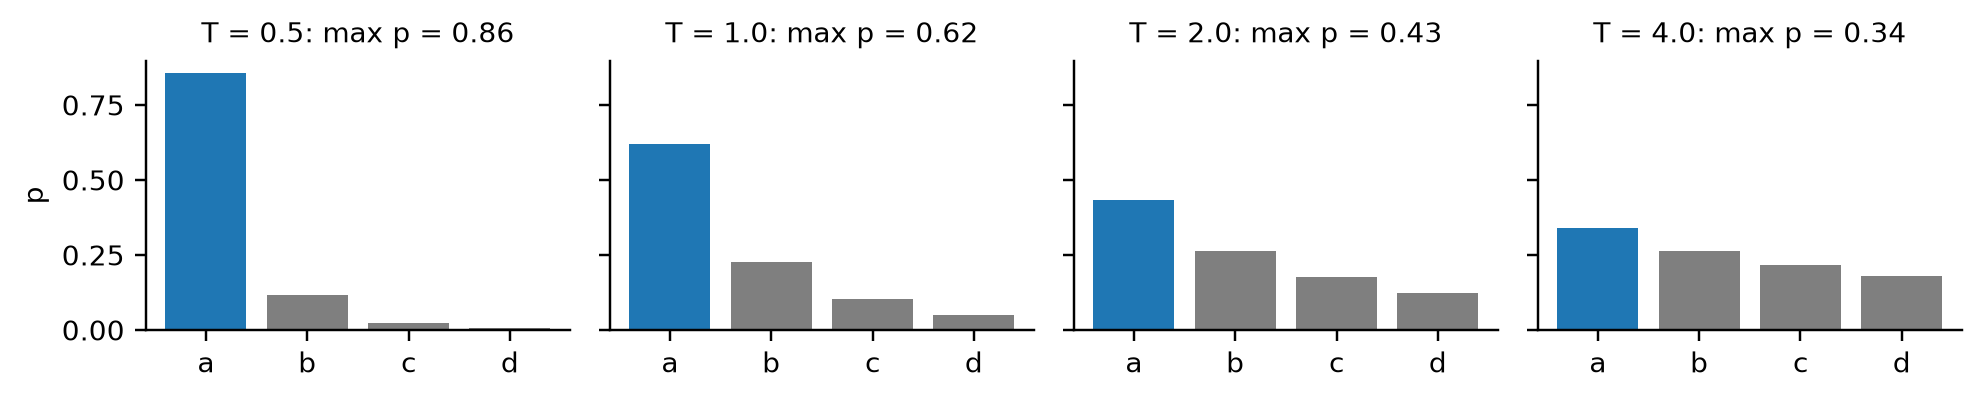

In [ ]:
#| code-fold: true
#| code-summary: figure code
zt = torch.tensor([2.0, 1.0, 0.2, -0.5])
fig, axs = plt.subplots(1, 4, figsize=(9, 1.9), sharey=True)
for ax, T in zip(axs, (0.5, 1.0, 2.0, 4.0)):
    pt = torch.softmax(zt / T, -1)
    ax.bar(range(4), pt, color=["C0"] + ["C7"] * 3); ax.set_title(f"T = {T}: max p = {pt.max():.2f}")
    ax.set_xticks(range(4), ["a", "b", "c", "d"])
axs[0].set_ylabel("p"); plt.tight_layout(); plt.show()

### Fitting one

The temperature of a bucket is the one that minimises the negative log-likelihood of the gold distributions over held-out rows,

$$\mathrm{NLL}(T) = -\frac{1}{N}\sum_{n=1}^{N}\sum_{i} t_{n,i}\,\log\mathrm{softmax}(z_n / T)_i,$$

Laya's `fit_one_temp`. The rows must be held out: on rows the model trained on it is near-certain and near-correct, so the fit would sharpen it further whatever it does on new rows; `fit_temperatures` only ever sees the calibration slice. In $\beta = 1/T$ the NLL is convex (its second derivative is the variance of $z$ under $p$), so it has a single minimum; like Laya, sysone fits $u = \log T$, which keeps $T$ positive but is not convex, as the finding below shows. Values are clamped to [0.5, 5], the range Laya's runtime applies, and `trace`, a list, collects every evaluation of the fit.

In [ ]:
#| exports
def fit_temperature(logits, targets, masks, min_rows:int=10, trace:list|None=None):
    "The temperature minimising the gold-distribution NLL of `logits` (rows, K), or None with fewer than `min_rows`"
    if len(logits) < min_rows: return None
    M = torch.as_tensor(np.asarray(masks)).bool()
    Z = torch.as_tensor(np.asarray(logits), dtype=torch.float32).masked_fill(~M, -1e4)
    T = torch.as_tensor(np.asarray(targets), dtype=torch.float32)
    def nll(log_t):
        logp = torch.log_softmax(Z / log_t.exp(), -1)
        # padded slots are masked out rather than multiplied by a zero target: a step to a tiny T sends
        # their logits to -inf, and 0 × -inf would poison the loss with NaN
        return -torch.where(M, T * logp, torch.zeros_like(logp)).sum(-1).mean()
    log_t = torch.zeros(1, requires_grad=True)
    opt = torch.optim.LBFGS([log_t], lr=1.0, max_iter=100, line_search_fn="strong_wolfe")
    def closure():
        opt.zero_grad(); loss = nll(log_t); loss.backward()
        if trace is not None: trace.append((log_t.item(), loss.item()))
        return loss
    opt.step(closure)
    t = log_t.exp().item()
    if not math.isfinite(t):  # a grid over [0.05, 20] as the fallback, should the optimiser ever fail
        grid = torch.linspace(math.log(0.05), math.log(20), 200)
        with torch.no_grad(): t = grid[torch.stack([nll(g) for g in grid]).argmin()].exp().item()
    return clamp_temperature(t)

Two synthetic buckets to fit, with gold distributions known by construction: an overconfident model whose logits are three times too large, which wants $T = 3$, and an underconfident noul model whose logits are four times too small, which wants $T = 0.25$ (the clamp raises that to 0.5 when it is stored):

In [ ]:
g = torch.Generator().manual_seed(0)
true_z = torch.randn(400, 4, generator=g) * 1.5
gold = torch.softmax(true_z, -1)
over = (3 * true_z, gold, torch.ones(400, 4).bool())
under = (0.25 * true_z[200:, :2], torch.softmax(true_z[200:, :2], -1), torch.ones(200, 2).bool())
T3 = fit_temperature(*over)
test_close(T3, 3.0, eps=0.05)
T3

2.999999523162842

The convexity in $\beta$, checked with autograd on the underconfident bucket: the first derivative of the NLL is the mean of $\sum_i (p_i - t_i) z_i$ and the second is the mean variance of $z$ under $p$, which cannot be negative. The optimiser works in $\log T$ all the same, and there the curvature can vanish, which is what the finding below is about.

In [ ]:
Zu, Tu, _ = under
beta = torch.tensor(1.0, requires_grad=True)
nll_beta = -(Tu * torch.log_softmax(Zu * beta, -1)).sum(-1).mean()
d1, = torch.autograd.grad(nll_beta, beta, create_graph=True)
d2, = torch.autograd.grad(d1, beta)
pu = torch.softmax(Zu, -1)
test_close(d1, ((pu - Tu) * Zu).sum(-1).mean(), eps=1e-5)
test_close(d2, ((pu * Zu ** 2).sum(-1) - (pu * Zu).sum(-1) ** 2).mean(), eps=1e-5)
d1.item(), d2.item()

(-0.10632878541946411, 0.06328226625919342)

::: {.callout-note title="Finding: Laya's fitter returns NaN on an underconfident model"}
Laya's notebook fits the temperature with `LBFGS(lr=0.1)` and no line search. Run verbatim on the two buckets above, it gets the overconfident one right after 70 evaluations; on the underconfident one it creeps towards the answer for 37 evaluations, then jumps to $T \approx 10^{-79}$ and returns NaN. sysone's fitter adds a strong-Wolfe line search and two guards, and needs 6 to 8 evaluations for either bucket.
:::

Laya's function, pasted from the notebook, with one line added to record its evaluations:

In [ ]:
def laya_fit_one_temp(sel, trace=None):
    # pasted from laya_finetune_typed_decisions_2xT4_kaggle.ipynb (Apache-2.0, Convai Innovations); `trace` added
    if len(sel) < 10:
        return 1.0
    kmax = max(len(z) for z, _ in sel)
    Z = torch.full((len(sel), kmax), -1e4)
    T = torch.zeros((len(sel), kmax))
    for i, (z, t) in enumerate(sel):
        Z[i, :len(z)] = torch.tensor(z)
        T[i, :len(t)] = torch.tensor(t, dtype=torch.float32)
    log_t = torch.zeros(1, requires_grad=True)
    opt = torch.optim.LBFGS([log_t], lr=0.1, max_iter=100)
    def closure():
        opt.zero_grad()
        loss = -(T * torch.log_softmax(Z / log_t.exp(), -1)).sum(-1).mean()
        loss.backward()
        if trace is not None: trace.append((log_t.item(), loss.item(), log_t.grad.item()))   # added
        return loss
    opt.step(closure)
    return float(torch.clamp(log_t.exp(), 0.1, 10.0).item())

as_sel = lambda Z, T, M: [(z[m].tolist(), t[m].tolist()) for z, t, m in zip(Z, T, M)]
runs = {}
for name, bucket in {"overconfident choice (wants T = 3)": over, "underconfident noul (wants T = 0.25)": under}.items():
    tl, ts = [], []
    runs[name] = dict(laya_T=laya_fit_one_temp(as_sel(*bucket), tl), laya_evals=len(tl),
                      sysone_T=fit_temperature(*bucket, trace=ts), sysone_evals=len(ts), traces=(tl, ts))
table = pd.DataFrame(runs).T.drop(columns="traces"); table

,laya_T,laya_evals,sysone_T,sysone_evals
overconfident choice (wants T = 3),2.995789,70,3.0,6
underconfident noul (wants T = 0.25),NaN,100,0.5,8


In [ ]:
test_eq(math.isnan(runs["underconfident noul (wants T = 0.25)"]["laya_T"]), True)
test_eq(runs["underconfident noul (wants T = 0.25)"]["sysone_T"], 0.5)          # 0.25, clamped
assert all(r["sysone_evals"] <= 10 for r in runs.values())

Why it happens. Without a line search, torch's LBFGS takes a fixed tenth (`lr=0.1`) of the step its curvature model proposes, which is why it creeps. It has no curvature to start from, so it estimates it from the last move $s$ and the change in slope $y$ that move caused; in one dimension its step is the secant step, $-g\,s/y$. The NLL in $\log T$ has an inflection point: going down from $T = 1$ its slope first grows, from 0.106 to 0.116, before falling to 0 at the minimum. Near the inflection the slope stops changing, $y \to 0$, and the secant step explodes. The last evaluations of Laya's run on the underconfident bucket:

In [ ]:
tl = runs["underconfident noul (wants T = 0.25)"]["traces"][0]
bad = next(i for i, (u, l, g_) in enumerate(tl) if not math.isfinite(l))
pd.DataFrame([dict(evaluation=i, log_T=u, T=math.exp(u) if math.isfinite(u) else float("nan"), nll=l, slope=g_) for i, (u, l, g_) in enumerate(tl)][bad - 4:bad + 2]).set_index("evaluation")

,log_T,T,nll,slope
evaluation,,,,
33,-0.370238,6.905702e-01,0.510493,0.116144
34,-0.381852,6.825960e-01,0.509144,0.116186
35,-0.393471,6.747111e-01,0.507794,0.116206
36,-0.405091,6.669159e-01,0.506444,0.116205
37,-181.649902,1.289584e-79,NaN,NaN
38,NaN,NaN,NaN,NaN


In [ ]:
(u0, _, g0), (u1, _, g1) = tl[bad - 2], tl[bad - 1]
{"move s": u1 - u0, "change in slope y": g1 - g0, "secant step −g·s/y": -g1 * (u1 - u0) / (g1 - g0), "jump taken": tl[bad][0] - u1}

{'move s': -0.01162061095237732,
 'change in slope y': -7.450580596923828e-07,
 'secant step −g·s/y': -1812.447051409781,
 'jump taken': -181.2448110282421}

The slope changed by less than a millionth ($-7 \times 10^{-7}$) while the point moved by 0.012, so the secant step is $-1{,}812$ in $\log T$; a tenth of it is taken, and the jump lands at $\log T = -181.6$, $T = 10^{-79}$, where $z/T$ overflows float32 and the log-softmax of $\infty - \infty$ is NaN. Every evaluation after that is NaN, and so is the returned temperature. The curve, with both fitters' evaluations on it:

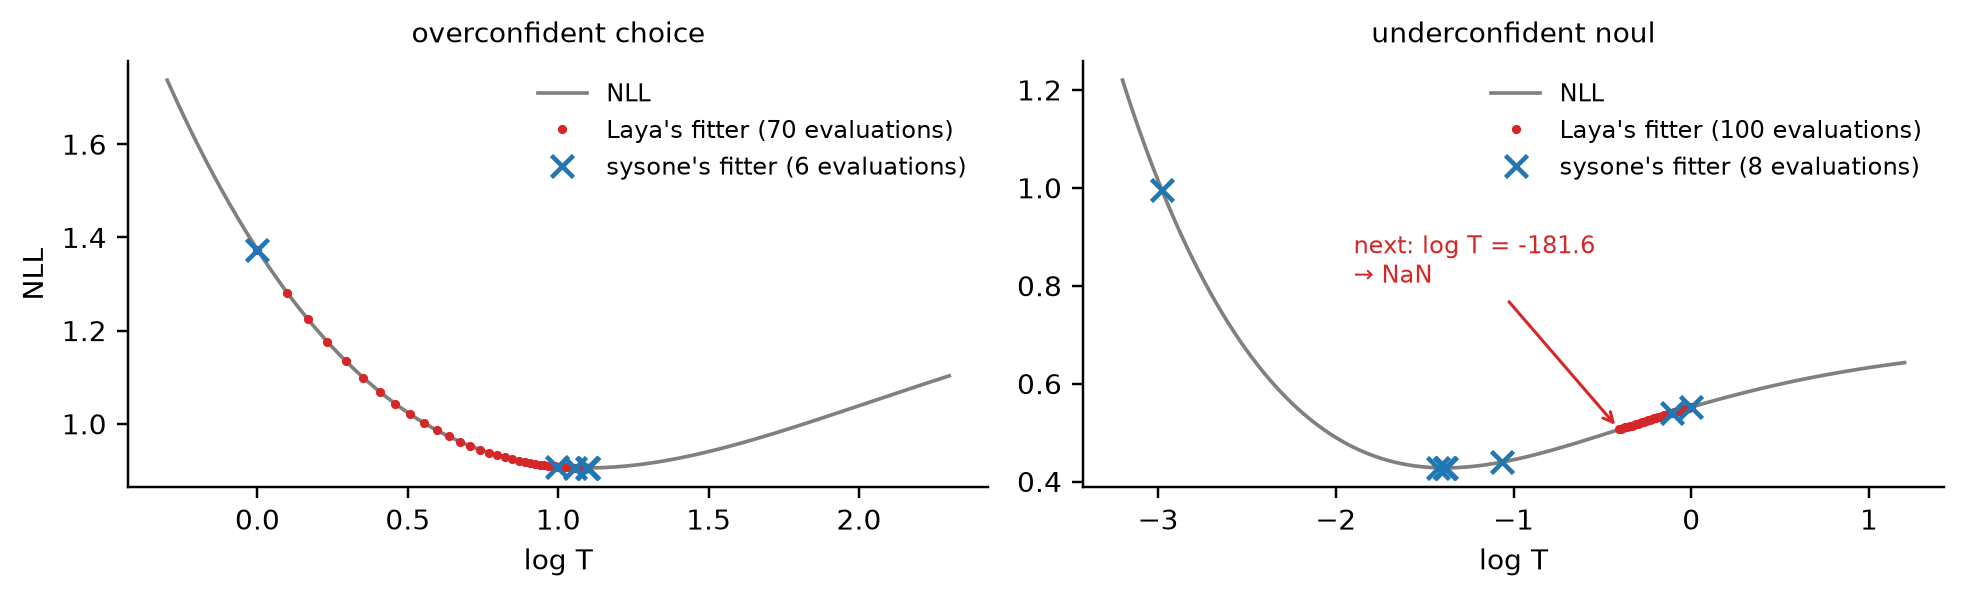

In [ ]:
#| code-fold: true
#| code-summary: figure code
fig, axs = plt.subplots(1, 2, figsize=(9, 2.8))
for ax, (name, bucket), (lo, hi) in zip(axs, {"overconfident choice": over, "underconfident noul": under}.items(), ((-0.3, 2.3), (-3.2, 1.2))):
    tl, ts = runs[next(k for k in runs if k.startswith(name))]["traces"]
    Zb, Tb, Mb = bucket
    us = torch.linspace(lo, hi, 400)
    ax.plot(us, [-(Tb * torch.log_softmax(Zb / math.exp(u), -1)).sum(-1).mean().item() for u in us], color="gray", lw=1.2, label="NLL")
    fin = [(u, l) for u, l, _ in tl if math.isfinite(l)]
    ax.plot(*zip(*fin), ".", color="C3", ms=4, label=f"Laya's fitter ({len(tl)} evaluations)")
    ax.plot(*zip(*ts), "x", color="C0", ms=7, mew=1.5, label=f"sysone's fitter ({len(ts)} evaluations)")
    if len(fin) < len(tl):
        ax.annotate(f"next: log T = {tl[len(fin)][0]:.1f}\n→ NaN", xy=fin[-1], xytext=(-1.9, fin[-1][1] + 0.3),
                    arrowprops=dict(arrowstyle="->", color="C3"), color="C3", fontsize=8)
    ax.set_title(name); ax.set_xlabel("log T"); ax.legend(loc="upper right")
axs[0].set_ylabel("NLL"); plt.tight_layout(); plt.show()

The fix is a line search. With `line_search_fn="strong_wolfe"` a step is tried before it is taken, and kept only if it lowers the loss enough (the Armijo condition) and leaves the slope flatter (the curvature condition); a trial at $T = 10^{-79}$ fails the first and is cut back. It also takes whole steps where they work, hence 6 to 8 evaluations instead of 70 to 100. Two guards stay for anything the line search does not catch. Padded slots are masked with `torch.where` rather than multiplied by their zero targets, because a trial at a tiny $T$ sends their logits to $-\infty$, and $0 \times (-\infty)$ is NaN even though the slot should contribute nothing:

In [ ]:
z_pad, t_pad, m_pad = torch.tensor([[1.0, 0.5, -1e4]]), torch.tensor([[0.7, 0.3, 0.0]]), torch.tensor([[True, True, False]])
logp = torch.log_softmax(z_pad / 1e-36, -1)         # the padded slot: -1e4 / 1e-36 is -inf in float32
multiplied, masked = (t_pad * logp).sum(), torch.where(m_pad, t_pad * logp, torch.zeros_like(logp)).sum()
test_eq((math.isnan(multiplied), math.isfinite(masked)), (True, True))
logp, multiplied, masked

(tensor([[ 0.0000e+00, -5.0000e+35,        -inf]]),
 tensor(nan),
 tensor(-1.5000e+35))

and, if the result is still not finite, a grid over $T \in [0.05, 20]$ picks the temperature.

### Buckets

`fit_temperatures` fits one temperature per question type, then one per type and option-count bucket (`choice:2`, `choice:3-5`, `choice:6-10`, `choice:11+`) where the bucket has at least `min_rows` rows. Different kinds of question need different corrections: the head-only ModernBERT-large run of the text notebook fitted 0.97 for choices, 1.17 for scores and 1.53 for nouls.

In [ ]:
#| export
def fit_temperatures(logits, targets, masks, qtypes, min_rows:int=10) -> dict:
    "Temperatures per question type (`choice`) and per type and option-count bucket (`choice:3-5`); unanswerable rows sit out"
    logits, targets, masks, qtypes = map(np.asarray, (logits, targets, masks, qtypes))
    keep = targets.sum(-1) > 0
    logits, targets, masks, qtypes = logits[keep], targets[keep], masks[keep], qtypes[keep]
    ks = masks.sum(-1)
    temps = {}
    for qt, name in QTYPE_NAMES.items():
        sel = qtypes == qt
        t = fit_temperature(logits[sel], targets[sel], masks[sel], min_rows)
        if t is not None: temps[name] = round(t, 4)
        buckets = np.array([temp_bucket(qt, k) for k in ks[sel]])
        for b in sorted(set(buckets)):
            bsel = np.flatnonzero(sel)[buckets == b]
            t = fit_temperature(logits[bsel], targets[bsel], masks[bsel], min_rows)
            if t is not None: temps[str(b)] = round(t, 4)
    return temps

In [ ]:
Z = torch.cat([2 * true_z[:200], torch.cat([0.25 * true_z[200:, :2], torch.full((200, 2), -1e4)], 1)])
Tg = torch.cat([gold[:200], torch.cat([torch.softmax(true_z[200:, :2], -1), torch.zeros(200, 2)], 1)])
M = torch.cat([torch.ones(200, 4), torch.cat([torch.ones(200, 2), torch.zeros(200, 2)], 1)]).bool()
Q = torch.tensor([QTYPES["choice"]] * 200 + [QTYPES["noul"]] * 200)
temps = fit_temperatures(Z, Tg, M, Q)
test_close(temps["choice:3-5"], 2.0, eps=0.05)
test_eq(temps["noul:2"], 0.5)    # logits 4× too small want T = 0.25; the clamp stops at 0.5
temps

{'choice': 2.0, 'choice:3-5': 2.0, 'noul': 0.5, 'noul:2': 0.5}

## Metrics

The definitions are those of Laya's evaluation cell, so a sysone run is comparable with the published numbers. Per decision: accuracy (the argmax against the gold label; for a noul, p(true) ≥ 0.5 against the gold truth value), and for choice and noul questions soft accuracy $\sum p\,g$, Brier $\sum (p - g)^2$, total variation and KL from gold; for score questions the absolute error of the expected level and whether it is within one level.

The *expected calibration error* sorts decisions into bins by their top probability and compares, in each bin, the mean confidence with the fraction that was right: $\mathrm{ECE} = \sum_b \frac{n_b}{N}\,\lvert \mathrm{conf}_b - \mathrm{acc}_b\rvert$. A calibrated model's decisions at confidence 0.8 are right 80% of the time and score 0. `ece_score` is Laya's, vendored.

In [ ]:
#| exports
def ece_score(conf, correct, bins:int=15) -> float:
    "Expected calibration error across equal-width confidence bins; from Laya"
    conf, correct = np.asarray(conf, dtype=float), np.asarray(correct, dtype=float)
    if len(conf) == 0: return float("nan")
    edges = np.linspace(0, 1, bins + 1)
    e = 0.0
    for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
        sel = (conf >= lo if i == 0 else conf > lo) & (conf <= hi)
        if sel.any(): e += sel.mean() * abs(conf[sel].mean() - correct[sel].mean())
    return float(e)

In [ ]:
rng = np.random.default_rng(0)
c = rng.uniform(0.3, 1, 20000)
test_close(ece_score(c, rng.uniform(size=c.shape) < c), 0.0, eps=0.01)   # calibrated: confidence = hit rate
test_close(ece_score(np.full(1000, 0.9), np.zeros(1000)), 0.9)

A reliability diagram draws the bins. For an overconfident model (logits three times too large, outcomes drawn from the true probabilities), the temperature fitted on one half of the rows closes the gap on the other half, without changing a single answer:

In [ ]:
g2 = torch.Generator().manual_seed(1)
zc = torch.randn(4000, 4, generator=g2) * 1.5
y = torch.multinomial(torch.softmax(zc, -1), 1, generator=g2)[:, 0]     # outcomes drawn from the true probabilities
model_z, fit_half, test_half = 3 * zc, slice(0, 2000), slice(2000, 4000)
T_fit = fit_temperature(model_z[fit_half], torch.softmax(zc[fit_half], -1), torch.ones(2000, 4).bool())
rel = {}
for name, T in (("before (T = 1)", 1.0), (f"after (T = {T_fit:.2f})", T_fit)):
    p_ = torch.softmax(model_z[test_half] / T, -1)
    rel[name] = (p_.max(-1).values.numpy(), (p_.argmax(-1) == y[test_half]).numpy())
eces = {k: round(ece_score(*v), 4) for k, v in rel.items()}
assert list(eces.values())[1] < list(eces.values())[0] / 3
test_eq(*[v[1].mean() for v in rel.values()])                          # same answers, same accuracy
eces

{'before (T = 1)': 0.2449, 'after (T = 3.00)': 0.026}

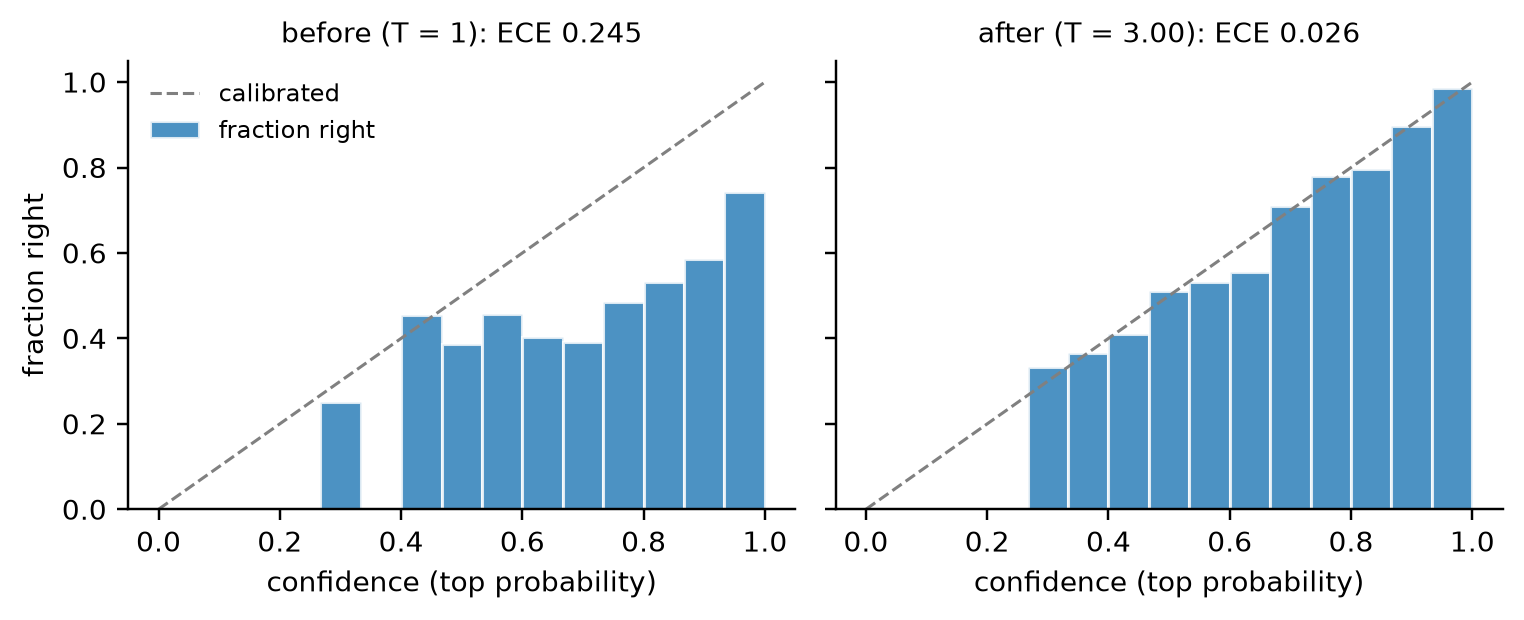

In [ ]:
#| code-fold: true
#| code-summary: figure code
fig, axs = plt.subplots(1, 2, figsize=(7, 2.9), sharey=True)
edges = np.linspace(0, 1, 16)
for ax, (name, (conf, ok)) in zip(axs, rel.items()):
    idx = np.clip(np.digitize(conf, edges[1:-1]), 0, 14)
    acc = np.array([ok[idx == b].mean() if (idx == b).any() else np.nan for b in range(15)])
    ax.bar(edges[:-1], acc, width=1 / 15, align="edge", color="C0", alpha=0.8, edgecolor="white", label="fraction right")
    ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="calibrated")
    ax.set_title(f"{name}: ECE {eces[name]:.3f}"); ax.set_xlabel("confidence (top probability)")
axs[0].set_ylabel("fraction right"); axs[0].legend(loc="upper left"); plt.tight_layout(); plt.show()

The per-decision values and their summary:

In [ ]:
#| export
def _decision(qt, p, g, label):
    "One decision's metric values, as the notebook computes them; the kind is the row's integer id, since tensors hold numbers, not classes"
    out = {}
    if qt == QTYPES["score"]:
        idx = np.arange(len(p))
        err = abs(float((idx * p).sum()) - float((idx * g).sum()))
        out.update(correct=float(int(p.argmax()) == label), conf=float(p.max()), mae=err, within_one=float(err <= 1.0))
        return out
    if qt == QTYPES["noul"]:
        out.update(correct=float(int(p[1] >= 0.5) == label), conf=float(max(p[1], 1 - p[1])))
    else: out.update(correct=float(int(p.argmax()) == label), conf=float(p.max()))
    out.update(soft=float((p * g).sum()), brier=float(((p - g) ** 2).sum()), tv=float(0.5 * np.abs(p - g).sum()),
               kl=float((g * np.log(np.clip(g / np.clip(p, 1e-12, None), 1e-12, 1e4))).sum()))
    return out

def _summarise(ds, qts):
    mean = lambda key, sel=None: float(np.mean([d[key] for d, q in zip(ds, qts) if key in d and (sel is None or q == sel)] or [np.nan]))
    m = {"accuracy": mean("correct"), "soft_accuracy": mean("soft"), "brier": mean("brier"), "kl": mean("kl"), "tv": mean("tv"),
         "ece": ece_score([d["conf"] for d in ds], [d["correct"] for d in ds]), "score_mae": mean("mae"),
         "within_one": mean("within_one"), "n": len(ds)}
    for qt, name in QTYPE_NAMES.items(): m[f"accuracy_{name}"] = mean("correct", qt)
    return m

def decision_metrics(logits, targets, masks, qtypes, labels, temperatures:dict|None=None, act=None, answerable=None) -> dict:
    "Accuracy, soft accuracy, Brier, KL, TV, ECE, score MAE and within-one over rows of logits; with `act` (p(act) per row), the act head's"
    logits, targets, masks, qtypes, labels = map(np.asarray, (logits, targets, masks, qtypes, labels))
    ds, qts, right = [], [], np.zeros(len(logits), bool)
    for i, (z, g, m, qt, lb) in enumerate(zip(logits, targets, masks, qtypes, labels)):
        k = int(m.sum())
        if g[:k].sum() <= 0: continue                         # unanswerable: no option is right, so no option metric applies
        z = z[:k].astype(np.float64) / lookup_temperature(temperatures, int(qt), k)
        p = np.exp(z - z.max()); p /= p.sum()
        d = _decision(int(qt), p, g[:k].astype(np.float64), int(lb)); ds.append(d); qts.append(int(qt)); right[i] = d["correct"] > 0
    out = _summarise(ds, qts) | {"n_unanswerable": int(len(logits) - len(ds))}
    if act is not None: out |= act_metrics(act, right, answerable)
    return out

In [ ]:
mets = decision_metrics(logits, target, mask, qtype, [0, 1, 1])
test_eq((mets["accuracy_choice"], mets["accuracy_noul"], mets["accuracy_score"]), (1.0, 0.0, 1.0))
un = decision_metrics(torch.cat([logits, logits[:1]]), torch.cat([target, torch.zeros_like(target[:1])]), torch.cat([mask, mask[:1]]),
                      torch.cat([qtype, qtype[:1]]), [0, 1, 1, -1])
test_eq((un["n"], un["n_unanswerable"], un["accuracy"]), (3, 1, mets["accuracy"]))       # an unanswerable row sits out
mets

{'accuracy': 0.6666666666666666,
 'soft_accuracy': 0.535318819554862,
 'brier': 0.07049416370793506,
 'kl': 0.13321175235327481,
 'tv': 0.1885558478352801,
 'ece': 0.47554012344538243,
 'score_mae': 0.1547819781773363,
 'within_one': 1.0,
 'n': 3,
 'accuracy_choice': 1.0,
 'accuracy_score': 1.0,
 'accuracy_noul': 0.0,
 'n_unanswerable': 0}

`macro_f1` averages each class's F1, per question, so a model that answers only the frequent classes cannot hide behind accuracy:

In [ ]:
#| export
def macro_f1(gold, pred) -> float:
    "The mean over the gold labels of each label's F1"
    gold, pred = [str(g) for g in gold], [str(p) for p in pred]
    f1 = []
    for c in sorted(set(gold)):
        tp = sum(g == c and p == c for g, p in zip(gold, pred))
        f1.append(2 * tp / max(1, 2 * tp + sum(g != c and p == c for g, p in zip(gold, pred)) + sum(g == c and p != c for g, p in zip(gold, pred))))
    return float(np.mean(f1)) if f1 else float("nan")

In [ ]:
test_eq(macro_f1(list("aabbc"), list("aabbc")), 1.0)
test_close(macro_f1(list("aaaab"), list("aaaaa")), (8 / 9 + 0) / 2, eps=1e-6)      # a: F1 8/9; b, never predicted: 0

## The act head

A model with an act head (see [models](03_models.ipynb#acting-or-escalating)) says, beside its answer, whether it should act on it. Its training signal is whether acting would have been right: act (class 0) where the gold is among the options and the top option is the gold, escalate (class 1) where it is not, either because the model is wrong or because the record says none of the options answers the question. Rows without gold teach it nothing. The targets come from the option head's current answers, so they change as the option head learns: early on most answers are wrong and the act head learns to escalate, and it learns to act as the answers get better.

The act probability then answers a selective-prediction question: acting only above a threshold, how often does the model act (coverage), and how often is it right when it does? `coverage_curve` traces that trade-off from the most confident case down, and `pick_threshold` fits the threshold on held-out rows, for a target accuracy on the cases acted on, or a target coverage.

In [ ]:
#| export
def act_targets(logits, label, answerable):
    "The act head's targets: 0 (act) where the gold is among the options and the top option is it, 1 (escalate) where not, -100 without gold"
    top = logits.detach().argmax(-1)
    t = torch.where((answerable == 1) & (top == label), 0, 1)
    return torch.where(answerable < 0, torch.full_like(t, -100), t)

def act_loss(act_logits, logits, label, answerable):
    "The act head's cross-entropy against `act_targets`"
    t = act_targets(logits, label, answerable)
    return F.cross_entropy(act_logits.float(), t, ignore_index=-100) if bool((t >= 0).any()) else act_logits.sum() * 0

def auroc(scores, labels) -> float:
    "Area under the ROC curve of `scores` against binary `labels` (NaN when one class is missing)"
    s, y = np.asarray(scores, float), np.asarray(labels, bool)
    if y.all() or not y.any(): return float("nan")
    order = np.argsort(s); ranks = np.empty(len(s)); ranks[order] = np.arange(1, len(s) + 1)
    for v in np.unique(s):                                          # average ranks of ties
        m = s == v; ranks[m] = ranks[m].mean()
    return float((ranks[y].sum() - y.sum() * (y.sum() + 1) / 2) / (y.sum() * (~y).sum()))

def coverage_curve(conf, correct) -> dict:
    "Coverage and accuracy when acting only on the cases at or above each confidence, from the most confident down"
    conf, correct = np.asarray(conf, float), np.asarray(correct, float)
    order = np.argsort(-conf, kind="stable"); n = np.arange(1, len(conf) + 1)
    return {"threshold": conf[order], "coverage": n / max(1, len(conf)), "accuracy": np.cumsum(correct[order]) / n}

def pick_threshold(conf, correct, accuracy:float|None=None, coverage:float|None=None) -> float:
    "The act threshold: the lowest keeping accuracy ≥ `accuracy` on the cases acted on (inf if none does), or the one acting on a `coverage` share"
    if (accuracy is None) == (coverage is None): raise ValueError("give accuracy= or coverage=")
    cv = coverage_curve(conf, correct)
    if not len(cv["threshold"]): return float("inf")
    if accuracy is not None:
        ok = np.flatnonzero(cv["accuracy"] >= accuracy)
        return float(cv["threshold"][ok.max()]) if len(ok) else float("inf")
    return float(cv["threshold"][int(np.clip(np.ceil(coverage * len(conf)) - 1, 0, len(conf) - 1))])

def selective_metrics(conf, correct, threshold) -> dict:
    "Coverage, and accuracy on the cases acted on, when acting where `conf >= threshold` (one threshold, or one per case)"
    conf, correct = np.asarray(conf, float), np.asarray(correct, bool)
    act = conf >= threshold
    return {"coverage": float(act.mean()) if len(conf) else float("nan"), "acted_accuracy": float(correct[act].mean()) if act.any() else float("nan")}

def act_metrics(act, right, answerable=None) -> dict:
    "How well p(act) separates the rows to act on (answerable and answered right) from the rest"
    act, right = np.asarray(act, float), np.asarray(right, bool)
    should = right & (np.asarray(answerable) == 1) if answerable is not None else right
    return {"act_auroc": auroc(act, should), "act_brier": float(((act - should) ** 2).mean()) if len(act) else float("nan")}

In [ ]:
zz = torch.tensor([[2.0, 0.1, 0.0], [0.1, 2.0, 0.0], [1.0, 0.0, 0.0], [0.0, 1.0, 0.0]])
lab, ans = torch.tensor([0, 0, -1, 1]), torch.tensor([1, 1, 0, -1])
test_eq(act_targets(zz, lab, ans).tolist(), [0, 1, 1, -100])          # right, wrong, unanswerable, no gold
test_eq(act_loss(torch.zeros(4, 2, requires_grad=True), zz, lab, ans).item() > 0, True)
rng = np.random.default_rng(0)
conf_ = rng.uniform(size=2000); right_ = rng.uniform(size=2000) < conf_       # confidence tracks correctness
tau = pick_threshold(conf_, right_, accuracy=0.9)
sm = selective_metrics(conf_, right_, tau)
test_eq(sm["acted_accuracy"] >= 0.9 and 0 < sm["coverage"] < 0.5, True)
test_close(pick_threshold(conf_, right_, coverage=0.25), np.quantile(conf_, 0.75), eps=0.01)
test_close(auroc(conf_, right_), 0.83, eps=0.02)
{"threshold": round(tau, 3)} | {k: round(v, 3) for k, v in sm.items()}

{'threshold': 0.754, 'coverage': 0.253, 'acted_accuracy': 0.901}

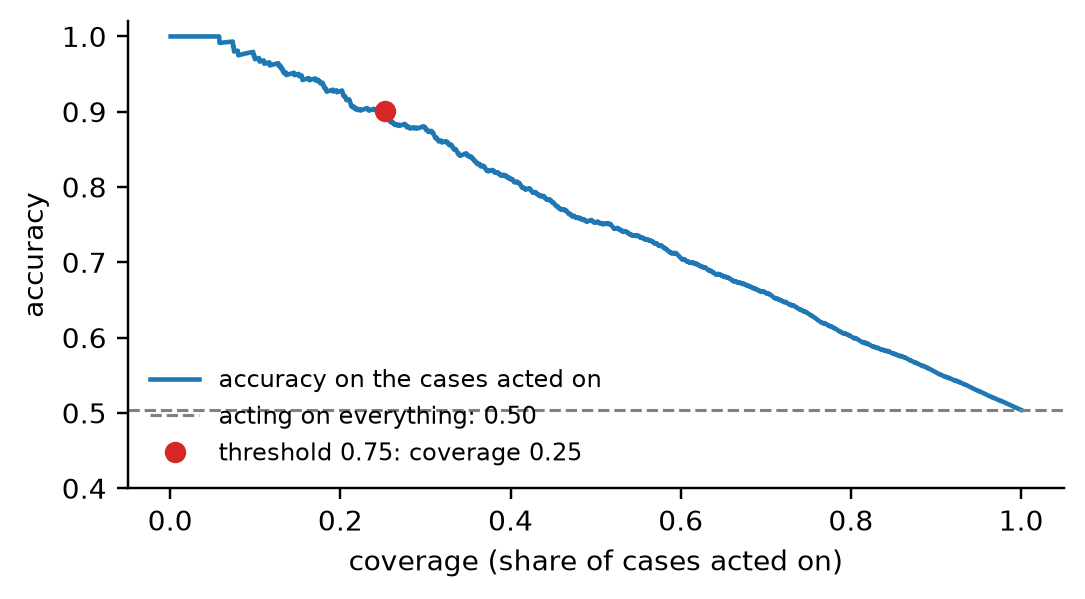

In [ ]:
#| code-fold: true
#| code-summary: figure code
cv = coverage_curve(conf_, right_)
fig, ax = plt.subplots(figsize=(5, 2.8))
ax.plot(cv["coverage"], cv["accuracy"], color="C0", lw=1.5, label="accuracy on the cases acted on")
ax.axhline(right_.mean(), color="gray", ls="--", lw=1, label=f"acting on everything: {right_.mean():.2f}")
ax.plot([sm["coverage"]], [sm["acted_accuracy"]], "o", color="C3", label=f"threshold {tau:.2f}: coverage {sm['coverage']:.2f}")
ax.set(xlabel="coverage (share of cases acted on)", ylabel="accuracy", ylim=(0.4, 1.02)); ax.legend(fontsize=8, frameon=False, loc="lower left")
plt.tight_layout(); plt.show()

One threshold for every question is a blunt rule when question kinds differ. A kind whose act scores run lower than the others', say a short list that often lacks the right answer, falls below a threshold set by the confident kinds and is never acted on, however good its answers are. `fit_thresholds` fits a threshold per question type and per option-count bucket, as the temperatures are fitted, wherever a group has `min_rows` rows, plus one over all rows (`all`) for the rest. Each group then meets the target on its own. Here, a noul whose scores run high and a choice whose scores run low: the single threshold never acts on the choice, and the per-bucket ones act on both at the target accuracy:

In [ ]:
#| export
def fit_thresholds(scores, right, qtypes, ks, accuracy:float=0.9, min_rows:int=10) -> dict:
    "Act thresholds for accuracy ≥ `accuracy` on the cases acted on: over all rows (`all`), and per question type and option-count bucket with ≥ `min_rows` rows"
    scores, right = np.asarray(scores, float), np.asarray(right, bool)
    names = np.array([q if isinstance(q, str) else QTYPE_NAMES[int(q)] for q in qtypes])
    buckets = np.array([temp_bucket(n, int(k)) for n, k in zip(names, ks)])
    out = {"all": pick_threshold(scores, right, accuracy=accuracy)}
    for key, sel in [(n, names == n) for n in np.unique(names)] + [(b, buckets == b) for b in np.unique(buckets)]:
        if sel.sum() >= min_rows: out[str(key)] = pick_threshold(scores[sel], right[sel], accuracy=accuracy)
    return out

def row_thresholds(thresholds, qtypes, ks) -> np.ndarray:
    "Each row's act threshold (`lookup_threshold`), for `selective_metrics`"
    return np.array([lookup_threshold(thresholds, q, int(k)) for q, k in zip(qtypes, ks)], dtype=float)

In [ ]:
rng = np.random.default_rng(1)
s_noul, s_choice = rng.uniform(0.6, 1.0, 400), rng.uniform(0.2, 0.6, 400)                  # the choice's scores run lower
r_noul, r_choice = rng.uniform(size=400) < (s_noul - 0.1), rng.uniform(size=400) < (s_choice + 0.35)
sc, rt = np.r_[s_noul, s_choice], np.r_[r_noul, r_choice]
qt, kk = np.r_[np.full(400, 2), np.zeros(400, int)], np.r_[np.full(400, 2), np.full(400, 4)]
ths = fit_thresholds(sc, rt, qt, kk, accuracy=0.85)
test_eq(set(ths), {"all", "noul", "noul:2", "choice", "choice:3-5"})
one, per = selective_metrics(sc, rt, ths["all"]), selective_metrics(sc, rt, row_thresholds(ths, qt, kk))
on_choice = lambda t: float((s_choice >= t).mean())
test_eq((on_choice(ths["all"]) < 0.05, on_choice(ths["choice:3-5"]) > 0.1, per["coverage"] > one["coverage"]), (True, True, True))
{"one threshold": {k: round(v, 3) for k, v in one.items()} | {"acts on the choice": round(on_choice(ths["all"]), 3)},
 "per bucket": {k: round(v, 3) for k, v in per.items()} | {"acts on the choice": round(on_choice(ths["choice:3-5"]), 3)}}

{'one threshold': {'coverage': 0.001,
  'acted_accuracy': 1.0,
  'acts on the choice': 0.0},
 'per bucket': {'coverage': 0.33,
  'acted_accuracy': 0.852,
  'acts on the choice': 0.657}}

`answer_metrics` computes the same values from answers in the Jev schema, the way the notebook scores `laya.Agent.predict` on the test split, so any backend that returns the schema, a sysone `Decider`, a Laya agent, a GLiNER2 decider or a remote Jev endpoint, can be scored the same way. It reads each answer back with `answer_probs` and `answer_index`, the core's [generic functions](00_core.ipynb#the-answer-schema) on the question's kind:

In [ ]:
#| export
def answer_metrics(cases) -> dict:
    "Notebook metrics over `(questions, answers, gold)` triples, one per case, with macro-F1 per question and, for answers with `action`, the act head's"
    ds, qts, per_q, acts = [], [], {}, []
    for questions, answers, gold in cases:
        for qid, qd in questions.items():
            if qid not in gold or qid not in answers: continue
            q, a = Question.from_dict(qd, name=qid), answers[qid]
            ok, right = q.answerable(gold[qid]), False
            if ok < 0: continue
            if ok == 1:
                t, label = q.target(gold[qid])
                p = answer_probs(q, a)                          # the distribution the answer states, whatever its kind
                d = _decision(q.qtype, p, np.asarray(t), label); ds.append(d); qts.append(q.qtype); right = d["correct"] > 0
                pred = answer_index(q, p)
                g, pk = per_q.setdefault(qid, ([], [])); g.append(str(q.keys[label])); pk.append(str(q.keys[pred]))
            if isinstance(a.get("action"), dict): acts.append((a["action"]["act_probability"], a["action"].get("act"), right, ok))
    m = _summarise(ds, qts) | {"macro_f1": float(np.mean([macro_f1(g, p) for g, p in per_q.values()])) if per_q else float("nan")}
    if acts:
        pa, right, ok = np.array([x[0] for x in acts], float), np.array([x[2] for x in acts], bool), np.array([x[3] for x in acts])
        m |= act_metrics(pa, right, ok)
        if all(x[1] is not None for x in acts): m |= selective_metrics(np.array([x[1] for x in acts], float), right, 0.5) | \
                                                    {"unanswerable_acted": float(np.mean([x[1] for x in acts if x[3] == 0])) if (ok == 0).any() else float("nan")}
    return m

In [ ]:
qs = {"a": {"type": "choice", "instructions": "x", "criteria": ["u", "v"]}, "b": {"type": "noul", "instructions": "y"},
      "c": {"type": "score", "instructions": "z", "criteria": ["0", "1", "2"]}}
ans = {"a": fill_answer(Question.from_dict(qs["a"]), [0.7, 0.3]), "b": fill_answer(Question.from_dict(qs["b"]), [0.4, 0.6]),
       "c": fill_answer(Question.from_dict(qs["c"]), [0.1, 0.2, 0.7])}
gold = {"a": {"label": "u"}, "b": {"noul": 0.3}, "c": {"label": "2", "probabilities": {"0": 0, "1": 0.2, "2": 0.8}}}
am = answer_metrics([(qs, ans, gold)])
test_eq((am["accuracy"], am["n"], am["macro_f1"]), (2 / 3, 3, 2 / 3))
test_close(am["score_mae"], abs(1.6 - 1.8))
am

{'accuracy': 0.6666666666666666,
 'soft_accuracy': 0.58,
 'brier': 0.18,
 'kl': 0.27023092066277227,
 'tv': 0.3,
 'ece': 0.4,
 'score_mae': 0.20000000000000018,
 'within_one': 1.0,
 'n': 3,
 'accuracy_choice': 1.0,
 'accuracy_score': 1.0,
 'accuracy_noul': 0.0,
 'macro_f1': 0.6666666666666666}

In [ ]:
iq = {"n": {"type": "choice", "instructions": "Pick a number", "criteria": [1, 2, 3]}}
oracle = [(iq, {"n": fill_answer(Question.from_dict(iq["n"]), np.eye(3)[g])}, {"n": {"label": g + 1}}) for g in (0, 1, 2)]
test_eq(answer_metrics(oracle)["accuracy"], 1.0)                                                # integer labels, in memory
test_eq(answer_metrics(json.loads(json.dumps(oracle)))["accuracy"], 1.0)                        # and over JSON
qa = Question.from_dict(qs["a"])
acting = [(qs, {"a": fill_answer(qa, [0.9, 0.1], act=0.9, act_threshold=0.5)}, {"a": {"label": "u"}}),        # acts, right
          (qs, {"a": fill_answer(qa, [0.2, 0.8], act=0.3, act_threshold=0.5)}, {"a": {"label": "u"}}),        # escalates, would be wrong
          (qs, {"a": fill_answer(qa, [0.6, 0.4], act=0.2, act_threshold=0.5)}, {"a": {"answerable": False}})] # escalates, none is right
amx = answer_metrics(acting)
test_eq((amx["n"], amx["coverage"], amx["acted_accuracy"], amx["unanswerable_acted"], amx["act_auroc"]), (2, 1 / 3, 1.0, 0.0, 1.0))

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()